# Pre-stimulus block (prior) decodability vs LDA 1
Per session x region (all neurons): mean population activity in a **pre-stimulus window**, embedded with PCA, decode **block 0.2 vs 0.8 (0.5 excluded)** with cross-validation for increasing #components (leak-free). Decodability saved per region/session/#components, then correlated with LDA 1 (per region, pooled mixed model, and all-data pooled).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from iblatlas.regions import BrainRegions
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'
out_path = prefix + 'neural/decoding/decoding_block_prestim_persession.parquet'

REGION_LEVEL = 'cosmos'
DROP = ['root', 'void']
PRESTIM_WIN = (-0.4, 0.0)  # pre-stimulus (pre-goCue) window
MAX_COMPONENTS = 30
CV_FOLDS = 5
MIN_NEURONS = 10
MIN_TRIALS = 40
N_EVAL = 10                # #components at which decodability is correlated with LDA 1
MIN_SESSIONS_CORR = 15
SEED = 0

trials_df = pd.read_parquet(trials_path)
block_by_session = {s: g.set_index('trial_id')['block'] for s, g in trials_df.groupby('session')}
lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
br = BrainRegions()
print("params set")

params set


## Load pre-stimulus window-averaged activity per session

In [3]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols])
pre_cols = [c for c, m in zip(tcols, (tsec >= PRESTIM_WIN[0]) & (tsec <= PRESTIM_WIN[1])) if m]
print(f"pre-stimulus bins: {len(pre_cols)}  ({PRESTIM_WIN})")

sess_pre = defaultdict(list); sess_block = {}
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        d['pre'] = d[pre_cols].mean(axis=1)
        piv = d.pivot_table(index='trial_id', columns='nuid', values='pre')
        amap = d.groupby('nuid')['area'].first()
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(amap.dropna().unique(), br.acronym2acronym(amap.dropna().unique(), mapping='Cosmos')))
            amap = amap.map(cmap)
        sess_pre[session].append((piv, amap))
        if session not in sess_block:
            blk = block_by_session.get(session, pd.Series(dtype=float)).reindex(piv.index)
            sess_block[session] = blk.map({0.2: 0.0, 0.8: 1.0})   # 0.5 -> NaN (excluded)
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")
print(f"Sessions loaded: {len(sess_pre)}")

pre-stimulus bins: 24  ((-0.4, 0.0))
  100/380 files...
  200/380 files...
  300/380 files...
Sessions loaded: 244


## Decode block (leak-free PCA) and save

In [4]:
def decode_curve(X, y, K, cv, seed=SEED):
    m = ~np.isnan(y) & ~np.isnan(X).any(axis=1)
    X, y = X[m], y[m].astype(int)
    n = X.shape[0]
    if n < MIN_TRIALS or len(np.unique(y)) < 2 or min(np.bincount(y)) < cv:
        return None, n
    K = min(K, X.shape[1], n - n // cv - 1)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    per_k = np.full((K, cv), np.nan)
    for fi, (tr, te) in enumerate(skf.split(X, y)):
        sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        nc = min(K, Xtr.shape[1], Xtr.shape[0] - 1)
        pca = PCA(n_components=nc, random_state=seed).fit(Xtr)
        Ztr, Zte = pca.transform(Xtr), pca.transform(Xte)
        for k in range(1, nc + 1):
            clf = LDA().fit(Ztr[:, :k], y[tr])
            per_k[k - 1, fi] = balanced_accuracy_score(y[te], clf.predict(Zte[:, :k]))
    return np.nanmean(per_k, axis=1), n

records = []
for si, session in enumerate(sess_pre):
    X = pd.concat([p for p, _ in sess_pre[session]], axis=1)
    areas = pd.concat([a for _, a in sess_pre[session]]); areas = areas[~areas.index.duplicated()]
    y = sess_block[session].reindex(X.index).values.astype(float)
    for region in pd.unique(areas.values):
        if region is None or (isinstance(region, float) and np.isnan(region)): continue
        cols = areas.index[areas.values == region]
        if len(cols) < MIN_NEURONS: continue
        accs, n_used = decode_curve(X[cols].values, y, MAX_COMPONENTS, CV_FOLDS)
        if accs is None: continue
        for k, a in enumerate(accs, start=1):
            if np.isfinite(a):
                records.append(dict(session=session, region=region, n_neurons=len(cols),
                                    n_trials=n_used, n_components=k, accuracy=float(a)))
    if (si + 1) % 50 == 0: print(f"  {si+1}/{len(sess_pre)} sessions...")

dec = pd.DataFrame(records)
dec.to_parquet(out_path)
print(f"Saved {len(dec)} rows; {dec.groupby(['session','region']).ngroups} session-region entries")

  50/244 sessions...
  100/244 sessions...
  150/244 sessions...
  200/244 sessions...
Saved 15187 rows; 587 session-region entries


## How decodable is block pre-stimulus? (vs #components)

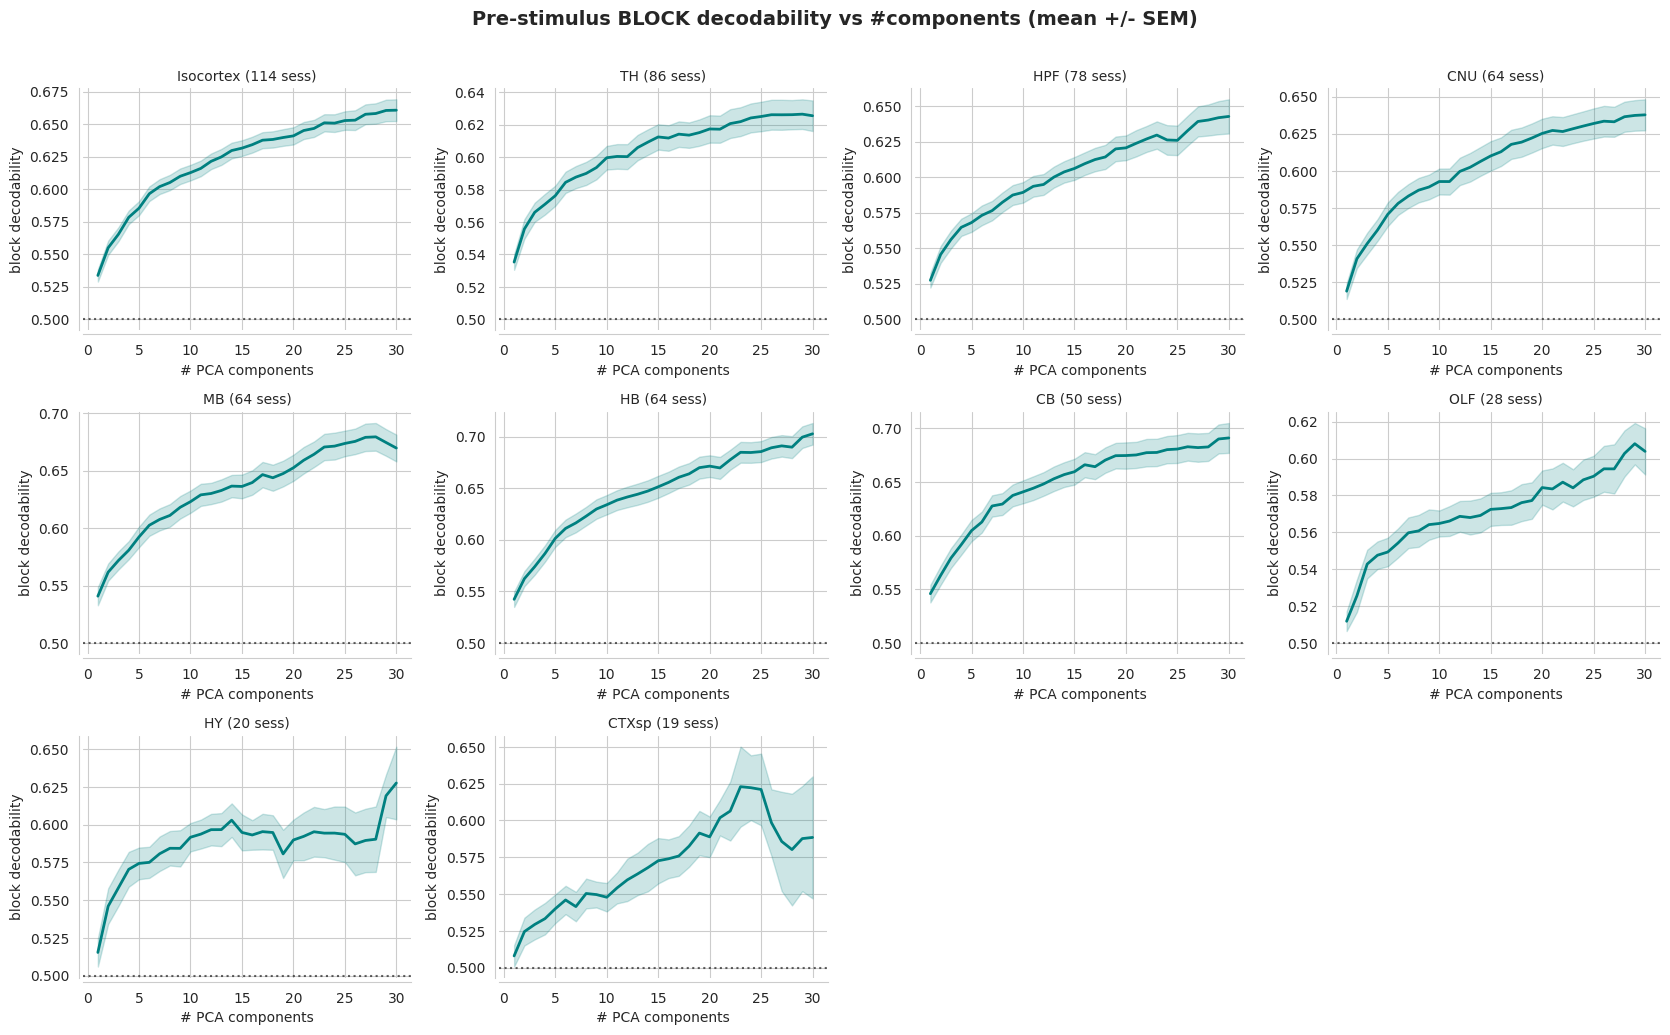

peak block decodability by region:
region
MB           0.888
Isocortex    0.848
CB           0.844
HB           0.818
HPF          0.807
CNU          0.807
TH           0.791
HY           0.706
CTXsp        0.691
OLF          0.687


In [5]:
regions = dec.groupby('region')['session'].nunique().sort_values(ascending=False)
regions = regions[regions >= 5].index.tolist()
ncols = 4; nrows = int(np.ceil(len(regions) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows), squeeze=False)
for i, r in enumerate(regions):
    ax = axes[i // ncols][i % ncols]
    m = dec[dec.region == r].groupby('n_components')['accuracy'].agg(['mean', 'sem'])
    ax.plot(m.index, m['mean'], color='teal', lw=2)
    ax.fill_between(m.index, m['mean'] - m['sem'], m['mean'] + m['sem'], color='teal', alpha=0.2)
    ax.axhline(0.5, color='black', ls=':', alpha=0.6)
    ax.set_title(f'{r} ({dec[dec.region==r]["session"].nunique()} sess)', fontsize=10)
    ax.set_xlabel('# PCA components'); ax.set_ylabel('block decodability')
    sns.despine(ax=ax, offset=3)
for i in range(len(regions), nrows * ncols): axes[i // ncols][i % ncols].axis('off')
fig.suptitle('Pre-stimulus BLOCK decodability vs #components (mean +/- SEM)', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("peak block decodability by region:")
print(dec.groupby('region')['accuracy'].max().sort_values(ascending=False).round(3).to_string())

## Correlate block decodability with LDA 1

In [6]:
sub = dec[dec['n_components'] == N_EVAL].merge(lda[['session', 'lda_1', 'mouse_name']], on='session').dropna(subset=['lda_1'])
well = sub.groupby('region')['session'].nunique(); well = well[well >= MIN_SESSIONS_CORR].index.tolist()
p = sub[sub.region.isin(well)]
print(f"n={len(sub)} at k={N_EVAL}; well-sampled regions: {well}\n")
for reg, g in p.groupby('region'):
    r, pv = pearsonr(g['lda_1'], g['accuracy']); rho, pvv = spearmanr(g['lda_1'], g['accuracy'])
    print(f"  {reg:10s} n={len(g):3d}: r={r:+.2f} p={pv:.3f} | rho={rho:+.2f} p={pvv:.3f}")
try:
    mm = smf.mixedlm("accuracy ~ lda_1 + C(region)", p, groups=p['mouse_name'],
                     vc_formula={'session': '0 + C(session)'}).fit(reml=True); mlab = 'mouse+session'
except Exception:
    mm = smf.mixedlm("accuracy ~ lda_1 + C(region)", p, groups=p['session']).fit(reml=True); mlab = 'session'
b, se, pv = mm.params['lda_1'], mm.bse['lda_1'], mm.pvalues['lda_1']
print(f"\nPOOLED block-decodability ~ lda_1 + C(region) + (1|mouse) [{mlab}]: coef={b:+.4f} z={b/se:+.2f} p={pv:.4f}")

n=587 at k=10; well-sampled regions: ['CB', 'CNU', 'CTXsp', 'HB', 'HPF', 'HY', 'Isocortex', 'MB', 'OLF', 'TH']

  CB         n= 50: r=+0.14 p=0.331 | rho=+0.17 p=0.250
  CNU        n= 64: r=-0.03 p=0.828 | rho=-0.02 p=0.867
  CTXsp      n= 19: r=+0.43 p=0.067 | rho=+0.39 p=0.101
  HB         n= 64: r=+0.18 p=0.152 | rho=+0.15 p=0.251
  HPF        n= 78: r=-0.04 p=0.708 | rho=-0.16 p=0.165
  HY         n= 20: r=-0.14 p=0.561 | rho=-0.13 p=0.591
  Isocortex  n=114: r=+0.25 p=0.007 | rho=+0.25 p=0.008
  MB         n= 64: r=+0.33 p=0.008 | rho=+0.28 p=0.023
  OLF        n= 28: r=+0.15 p=0.437 | rho=+0.29 p=0.128
  TH         n= 86: r=+0.09 p=0.402 | rho=+0.14 p=0.206

POOLED block-decodability ~ lda_1 + C(region) + (1|mouse) [mouse+session]: coef=+0.0030 z=+3.14 p=0.0017


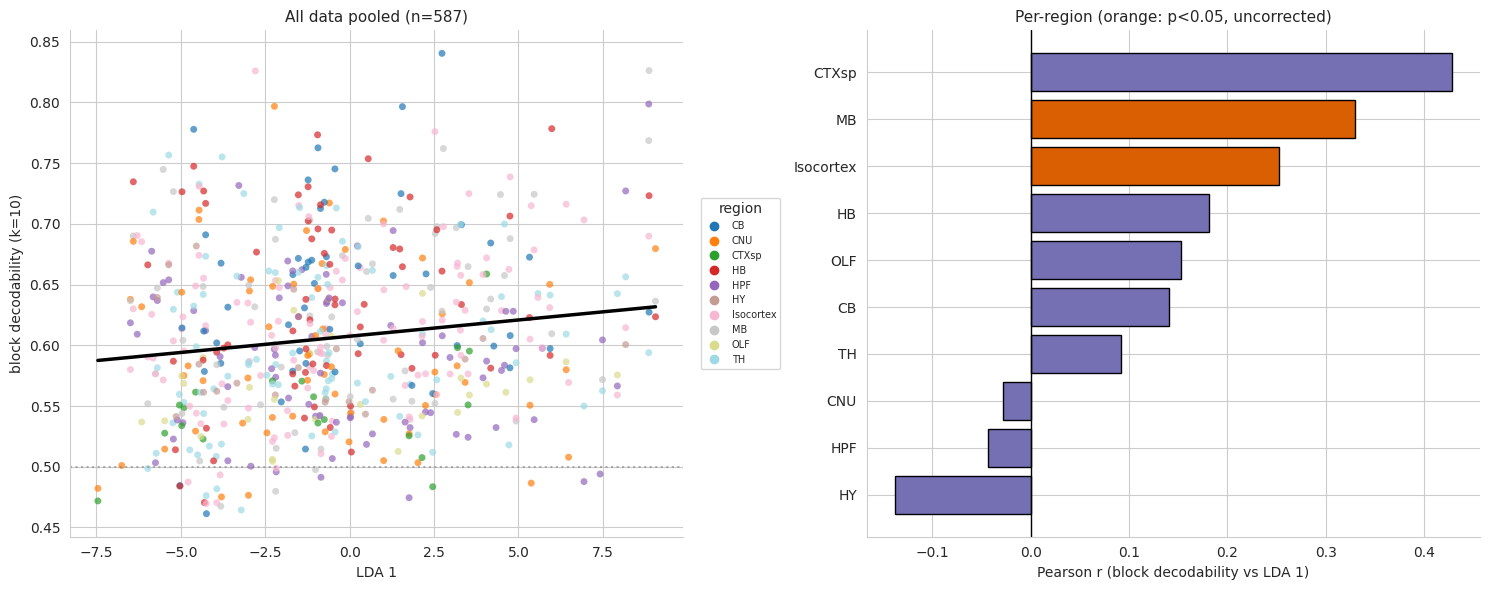

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# per-region scatter grid is large; show (left) all-data pooled, (right) per-region r bar
x = p['lda_1'].values; y = p['accuracy'].values
r, pv = pearsonr(x, y); rho, pvv = spearmanr(x, y)
region_list = sorted(p['region'].unique())
pal = dict(zip(region_list, plt.cm.tab20(np.linspace(0, 1, len(region_list)))))
axes[0].scatter(x, y, c=[pal[rr] for rr in p['region']], s=25, alpha=0.7, edgecolors='none')
z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
axes[0].plot(xl, np.polyval(z, xl), 'k-', lw=2.5, label=f'r={r:.3f} p={pv:.2e}\nrho={rho:.3f} p={pvv:.2e}')
axes[0].axhline(0.5, color='gray', ls=':', alpha=0.6)
axes[0].set_xlabel('LDA 1'); axes[0].set_ylabel(f'block decodability (k={N_EVAL})')
axes[0].set_title(f'All data pooled (n={len(p)})', fontsize=11); axes[0].legend(fontsize=10)
handles = [plt.Line2D([0], [0], marker='o', ls='', color=pal[rr], label=rr) for rr in region_list]
axes[0].legend(handles=handles, fontsize=7, loc='center left', bbox_to_anchor=(1.02, 0.5), title='region')
rs = sorted([(reg, pearsonr(g['lda_1'], g['accuracy'])[0], pearsonr(g['lda_1'], g['accuracy'])[1])
             for reg, g in p.groupby('region')], key=lambda t: t[1])
cols = ['#d95f02' if pp < 0.05 else '#7570b3' for _, _, pp in rs]
axes[1].barh([t[0] for t in rs], [t[1] for t in rs], color=cols, edgecolor='black')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('Pearson r (block decodability vs LDA 1)')
axes[1].set_title('Per-region (orange: p<0.05, uncorrected)', fontsize=11)
sns.despine(); plt.tight_layout(); plt.show()